In [23]:
import numpy as np 
import pandas as  pd 


In [24]:
import gensim
import os

In [59]:
import nltk

nltk.download('stopwords')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Tanjir\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping corpora\stopwords.zip.


True

In [61]:
import os
import nltk

from nltk import sent_tokenize
from nltk.corpus import stopwords
from gensim.utils import simple_preprocess

stop_words = set(stopwords.words('english'))

story = []

for filename in os.listdir('data'):

    with open(os.path.join('data', filename), encoding='latin-1') as f:
        corpus = f.read()

    raw_sent = sent_tokenize(corpus)

    for sent in raw_sent:
        words = simple_preprocess(sent)

        filtered_words = [
            word for word in words
            if word not in stop_words
        ]

        story.append(filtered_words)

print(story[:5])

[['game', 'thrones', 'book', 'one', 'song', 'ice', 'fire', 'george', 'martin', 'prologue', 'start', 'back', 'gared', 'urged', 'woods', 'began', 'grow', 'dark', 'around'], ['wildlings', 'dead'], ['dead', 'frighten'], ['ser', 'waymar', 'royce', 'asked', 'hint', 'smile'], ['gared', 'rise', 'bait']]


In [63]:
len(story)

145020

In [64]:
model = gensim.models.Word2Vec( window=10,min_count=5)

In [65]:
model.build_vocab(story)

In [66]:
model.train(story,total_examples=model.corpus_count,epochs=model.epochs)

Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'


(4314370, 4579390)

In [67]:
model.wv.most_similar("daenerys")

[('stormborn', 0.8816462755203247),
 ('unburnt', 0.8336915969848633),
 ('court', 0.7973378300666809),
 ('targaryen', 0.7910853624343872),
 ('myrcella', 0.7848761677742004),
 ('westeros', 0.783251941204071),
 ('elia', 0.7828916311264038),
 ('dorne', 0.7797841429710388),
 ('viserys', 0.779460072517395),
 ('brokered', 0.7791800498962402)]

In [68]:
model.wv.doesnt_match(["jon","rinko","araya"])

'jon'

In [69]:
model.wv['king']

array([-0.6966772 , -0.39353523,  1.1351237 ,  1.4601789 , -1.1246176 ,
       -0.16116478, -0.13096566, -1.1906244 , -0.9408008 ,  0.09560011,
       -0.1327514 ,  0.407056  ,  0.85868156,  0.03167287, -0.5055559 ,
        1.8210757 ,  1.3213471 , -0.07968081, -0.36340955, -0.63125885,
       -0.2963234 ,  1.5966994 ,  0.37232074, -3.7127085 ,  0.8574511 ,
        1.6664948 , -1.5560488 , -1.177995  , -1.0958933 ,  1.45848   ,
       -0.87545955,  1.998248  , -0.9969081 , -0.46825877, -0.4667563 ,
       -0.20569493, -1.3989398 , -0.79599524, -1.0364125 ,  0.06585941,
        1.8187402 , -0.6919728 , -0.3243354 ,  1.1989799 ,  1.3358182 ,
       -1.0594593 , -1.4093834 , -0.09225167,  2.088243  ,  0.557919  ,
       -2.376913  , -0.5828014 ,  2.634924  , -0.88260454, -0.5448888 ,
        3.3197181 , -1.5940375 ,  1.9734261 , -0.8781098 ,  2.9569254 ,
        1.1863316 ,  0.48250902, -2.080167  ,  1.7179754 , -0.3228056 ,
       -0.83112806, -1.8217678 ,  2.2464976 ,  0.7381077 , -0.01

In [70]:
model.wv['king'].shape

(100,)

In [71]:
#model.wv.similarity('aray','sans')
model.wv.similarity('cersei','sansa')

np.float32(0.6524166)

In [72]:
y = model.wv.index_to_key

In [73]:
model.wv.get_normed_vectors()

array([[-0.02200368,  0.03758585, -0.0201703 , ..., -0.06807931,
        -0.13150953,  0.19771852],
       [-0.18290432,  0.10762229,  0.09475158, ..., -0.12374592,
        -0.12470407,  0.21404655],
       [-0.06623561, -0.00057874, -0.01102413, ..., -0.15766132,
         0.0642485 , -0.17168191],
       ...,
       [-0.15850057,  0.06258986,  0.06288011, ..., -0.21464516,
         0.08577964,  0.15512846],
       [-0.10684878,  0.11952068,  0.12884608, ..., -0.16169652,
         0.07296481,  0.01868768],
       [-0.10415658,  0.05964068,  0.06314939, ..., -0.12097884,
         0.08708778, -0.02312238]], dtype=float32)

In [74]:
len(y)

11618

In [75]:
from sklearn.decomposition import PCA

In [76]:
pca = PCA(n_components=5)

In [77]:
X = pca.fit_transform(model.wv.get_normed_vectors())

In [78]:
X[:5]

array([[ 0.5062328 ,  0.02127652,  0.24648134,  0.18118553, -0.5036986 ],
       [ 0.40945786,  0.5417911 ,  0.39961123,  0.23695087, -0.34606916],
       [ 0.5141471 , -0.06259607, -0.3323115 ,  0.40607727, -0.39412487],
       [ 0.02105246,  0.12833664, -0.00464334,  0.21183771, -0.43859452],
       [ 0.28906804,  0.51512593,  0.5477845 ,  0.2195817 , -0.23310232]],
      dtype=float32)

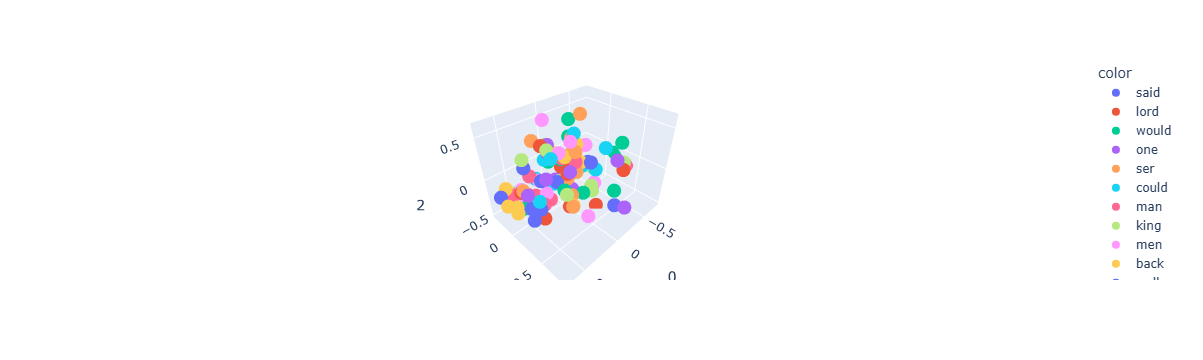

In [79]:
import plotly.express as px 
fig = px.scatter_3d(X[:100],x=0,y=1,z=2,color=y[:100])
fig.show()

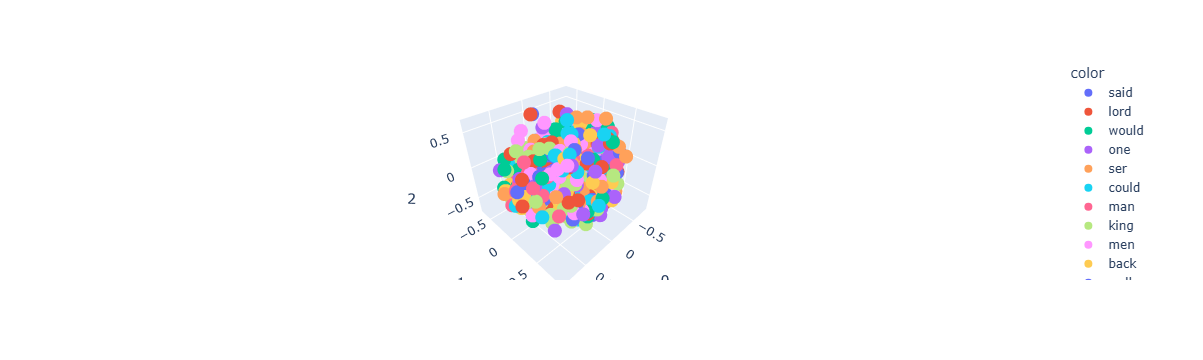

In [80]:
import plotly.express as px 
fig = px.scatter_3d(X[:500],x=0,y=1,z=2,color=y[:500])
fig.show()